<a href="https://www.kaggle.com/code/sonawanelalitsunil/2025-nvidia-stock-analysis-and-trends?scriptVersionId=223132276" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nvidia-stocks-data-2025/NVDA.csv



<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 "2025 NVIDIA Stock Analysis and Trends"  🚀


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 Import dependancies  🚀

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 Import dataset 🚀

In [3]:
df = pd.read_csv("/kaggle/input/nvidia-stocks-data-2025/NVDA.csv")

In [4]:
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,1999-01-22,0.037615,0.041016,0.048828,0.038802,0.043750,2714688000
1,1999-01-25,0.041556,0.045313,0.045833,0.041016,0.044271,510480000
2,1999-01-26,0.038331,0.041797,0.046745,0.041146,0.045833,343200000
3,1999-01-27,0.038212,0.041667,0.042969,0.039583,0.041927,244368000
4,1999-01-28,0.038092,0.041536,0.041927,0.041276,0.041667,227520000


In [5]:
df.tail()

,Date,Adj Close,Close,High,Low,Open,Volume
6553,2025-02-10,133.570007,133.570007,135.000000,129.960007,130.089996,216989100
6554,2025-02-11,132.800003,132.800003,134.479996,131.020004,132.580002,178902400
6555,2025-02-12,131.139999,131.139999,132.240005,129.080002,130.020004,160278600
6556,2025-02-13,135.289993,135.289993,136.500000,131.169998,131.559998,197430000
6557,2025-02-14,138.850006,138.850006,139.250000,135.500000,136.479996,194892300


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6558 entries, 0 to 6557
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6558 non-null   object 
 1   Adj Close  6558 non-null   float64
 2   Close      6558 non-null   float64
 3   High       6558 non-null   float64
 4   Low        6558 non-null   float64
 5   Open       6558 non-null   float64
 6   Volume     6558 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 358.8+ KB


In [7]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,6558.000000,6558.000000,6558.000000,6558.000000,6558.000000,6.558000e+03
mean,8.768532,8.795447,8.956567,8.618315,8.795850,5.991103e+08
std,23.907205,23.904882,24.349618,23.419200,23.922708,4.307236e+08
min,0.031286,0.034115,0.035547,0.033333,0.034896,1.968000e+07
25%,0.257739,0.281042,0.288511,0.273354,0.280810,3.384780e+08
50%,0.437176,0.466083,0.472875,0.459250,0.466584,5.002635e+08
75%,4.597059,4.644625,4.724000,4.588750,4.632437,7.307002e+08
max,149.429993,149.429993,153.130005,147.820007,153.029999,9.230856e+09


In [8]:
df.isnull().sum()

Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [9]:
df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 EDA  🚀

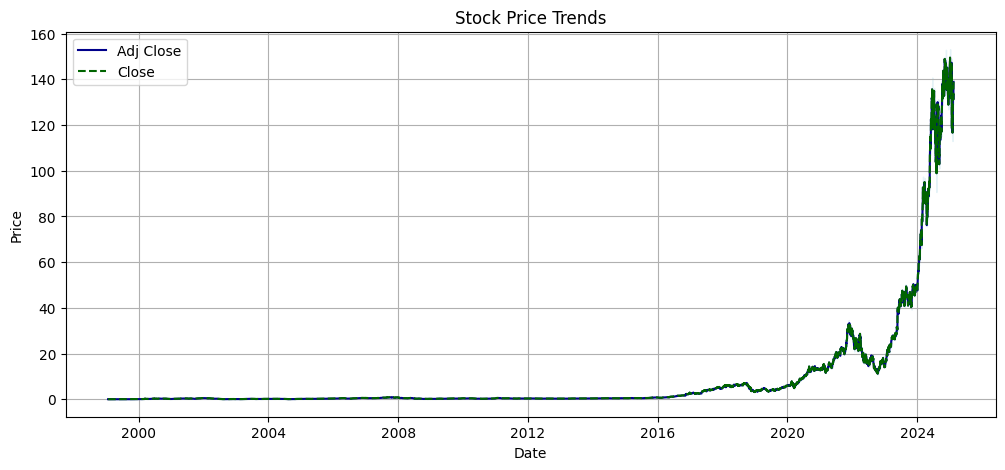

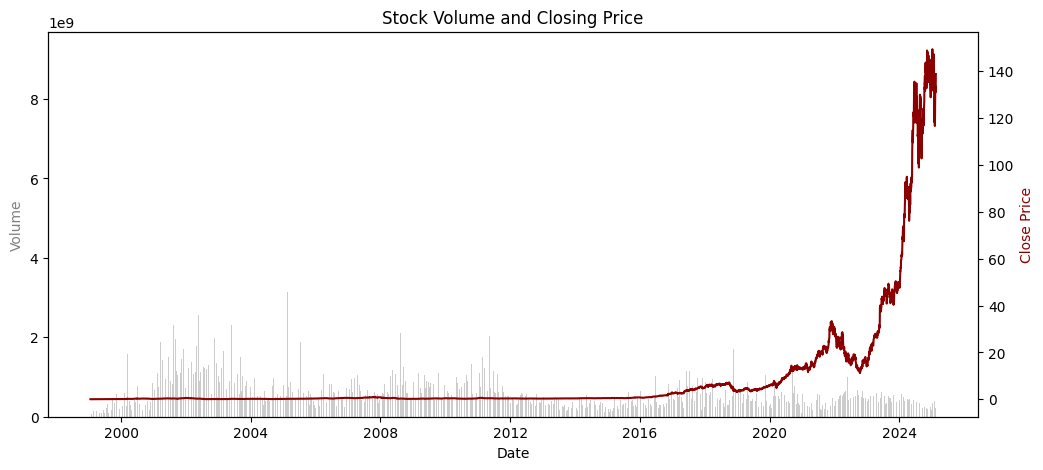

In [10]:
import plotly.graph_objects as go

df = pd.read_csv('/kaggle/input/nvidia-stocks-data-2025/NVDA.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)

# --- 1. Time Series Line Plot ---
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Adj Close'], label='Adj Close', color='darkblue')
plt.plot(df['Date'], df['Close'], label='Close', linestyle='dashed', color='darkgreen')
plt.fill_between(df['Date'], df['Low'], df['High'], color='lightblue', alpha=0.3)
plt.title('Stock Price Trends')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

# --- 2. Candlestick Chart ---
fig = go.Figure(data=[go.Candlestick(x=df['Date'],
                                     open=df['Open'],
                                     high=df['High'],
                                     low=df['Low'],
                                     close=df['Close'])])
fig.update_layout(title='Candlestick Chart', xaxis_title='Date', yaxis_title='Price', template='plotly_dark')
fig.show()

# --- 3. Volume vs. Close Price ---
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.bar(df['Date'], df['Volume'], alpha=0.4, color='gray', label='Volume')
ax2 = ax1.twinx()
ax2.plot(df['Date'], df['Close'], color='darkred', label='Close Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Volume', color='gray')
ax2.set_ylabel('Close Price', color='darkred')
plt.title('Stock Volume and Closing Price')
plt.show()


In [11]:
# Load and process data
df = pd.read_csv('/kaggle/input/nvidia-stocks-data-2025/NVDA.csv', parse_dates=['Date']).sort_values('Date')
df['50D_MA'] = df['Close'].rolling(50).mean()
df['200D_MA'] = df['Close'].rolling(200).mean()

# Create figure
fig = go.Figure([
    go.Scatter(x=df['Date'], y=df['Close'], name='Close Price', line=dict(color='cyan')),
    go.Scatter(x=df['Date'], y=df['50D_MA'], name='50-Day MA', line=dict(color='orange')),
    go.Scatter(x=df['Date'], y=df['200D_MA'], name='200-Day MA', line=dict(color='magenta'))
])

fig.update_layout(title="Close Price with Moving Averages", template="plotly_dark")
fig.show()

Mean Squared Error: 0.4070314794762368


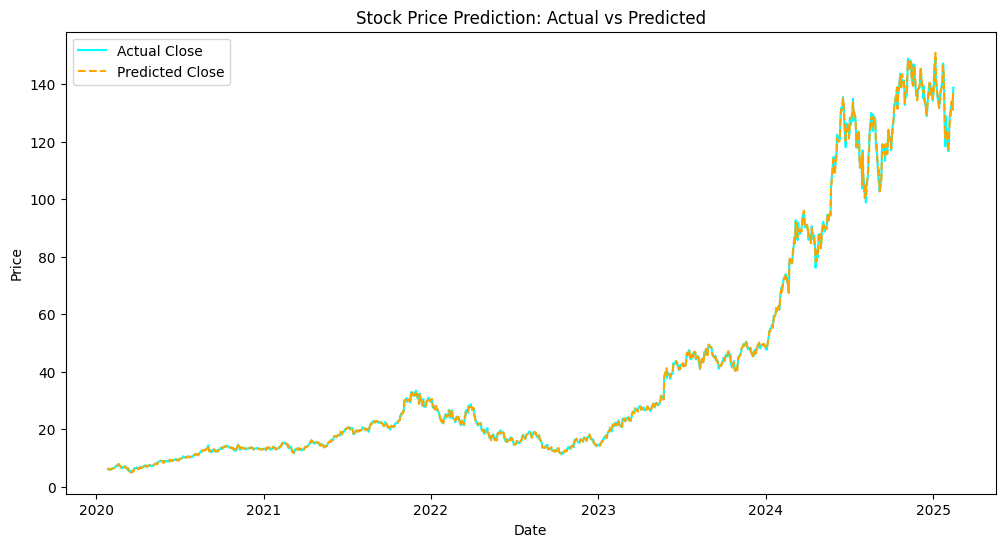

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Feature Engineering: Adding simple moving averages
df['50D_MA'] = df['Close'].rolling(window=50).mean()
df['200D_MA'] = df['Close'].rolling(window=200).mean()
df['Daily_Return'] = df['Close'].pct_change()

# Drop missing values from the newly created columns
df.dropna(inplace=True)

# Features and Target
features = ['Open', 'High', 'Low', 'Volume', '50D_MA', '200D_MA', 'Daily_Return']
target = 'Close'

# Train-Test Split (80% Train, 20% Test)
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Model: Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate the model: Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Plot actual vs predicted Close prices
plt.figure(figsize=(12,6))
plt.plot(df['Date'].iloc[len(X_train):], y_test, label='Actual Close', color='cyan')
plt.plot(df['Date'].iloc[len(X_train):], y_pred, label='Predicted Close', linestyle='dashed', color='orange')
plt.title('Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


# Thank you!!!